In [ ]:
import pickle

import jax
import jax.numpy as jnp

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns  

import liesel.model as lsl
import liesel.goose as gs

from tensorflow_probability.substrates.jax.experimental import distributions as tfde
from tensorflow_probability.python.internal.backend.jax.compat import v2 as tf
import tensorflow_probability.substrates.jax.distributions as tfd
import tensorflow_probability.substrates.jax.bijectors as tfb

In [27]:
# Define parameters 
k_dim = 5       # Dimension of covariance matrix 
n_units = 10000  # Number of decision-making units

def simulate_data(seed=42, n_units=n_units, n_alts=5):
    key = jax.random.PRNGKey(seed)
    k_beta, k_price, k_choice = jax.random.split(key, 3)
    
    # 1. Configuration & Parameters
    n_params = 5
    n_obs_small, n_obs_large = 5, 50
    counts = jnp.array([n_obs_small] * (n_units // 2) + [n_obs_large] * (n_units // 2))
    total_obs = jnp.sum(counts)
    unit_idx = jnp.repeat(jnp.arange(n_units), counts)

    # 2. True Parameter Definitions
    true_mu = jnp.array([1.0, -1.0, 0.0, 0.0, -3.0])
    true_Sigma = 3.0 * jnp.eye(n_params)
    true_Sigma = true_Sigma.at[3, 4].set(1.5).at[4, 3].set(1.5)

    # 3. Generate Latent Betas (Hierarchical)
    beta_dist = tfd.MultivariateNormalFullCovariance(loc=true_mu, covariance_matrix=true_Sigma)
    betas = beta_dist.sample(seed=k_beta, sample_shape=(n_units,))
    
    # 4. Generate Features (Price) for all observations at once
    # We generate for the total_obs rather than looping per unit
    prices = jax.random.uniform(k_price, shape=(total_obs, n_alts), minval=-1.5, maxval=0.0)

    # 5. Construct Design Matrix (X) using Broadcasting
    # Create identity structure for the first 4 alts, then append price
    identities = jnp.eye(n_alts, n_params - 1) # (5, 4)
    # Broadcast identities to (total_obs, 5, 4)
    X_fixed = jnp.broadcast_to(identities, (total_obs, n_alts, n_params - 1))
    # Concatenate price as the 5th column: (total_obs, 5, 5)
    X = jnp.concatenate([X_fixed, prices[..., jnp.newaxis]], axis=-1)

    # 6. Calculate Logits & Sample Choices
    # Map betas to the observation level using unit_idx
    obs_betas = betas[unit_idx] # (total_obs, 5)
    
    # Efficiently compute: logits[i, j] = sum_k X[i, j, k] * beta[i, k]
    logits = jnp.einsum('ijk,ik->ij', X, obs_betas)
    choices = tfd.Categorical(logits=logits).sample(seed=k_choice)

    return {
        "X": X,
        "y": choices,
        "betas": betas,
        "unit_idx": unit_idx,
        "true_mu": true_mu,
        "true_Sigma": true_Sigma
    }

# Genearete data
data = simulate_data()

In [28]:
# Read data with 1000 decision making units
filename = "mcmc_results_rossi_large_10000n.pkl"

# Load the results object
with open(filename, "rb") as f:
    results = pickle.load(f)

print("Results successfully loaded")

Results successfully loaded


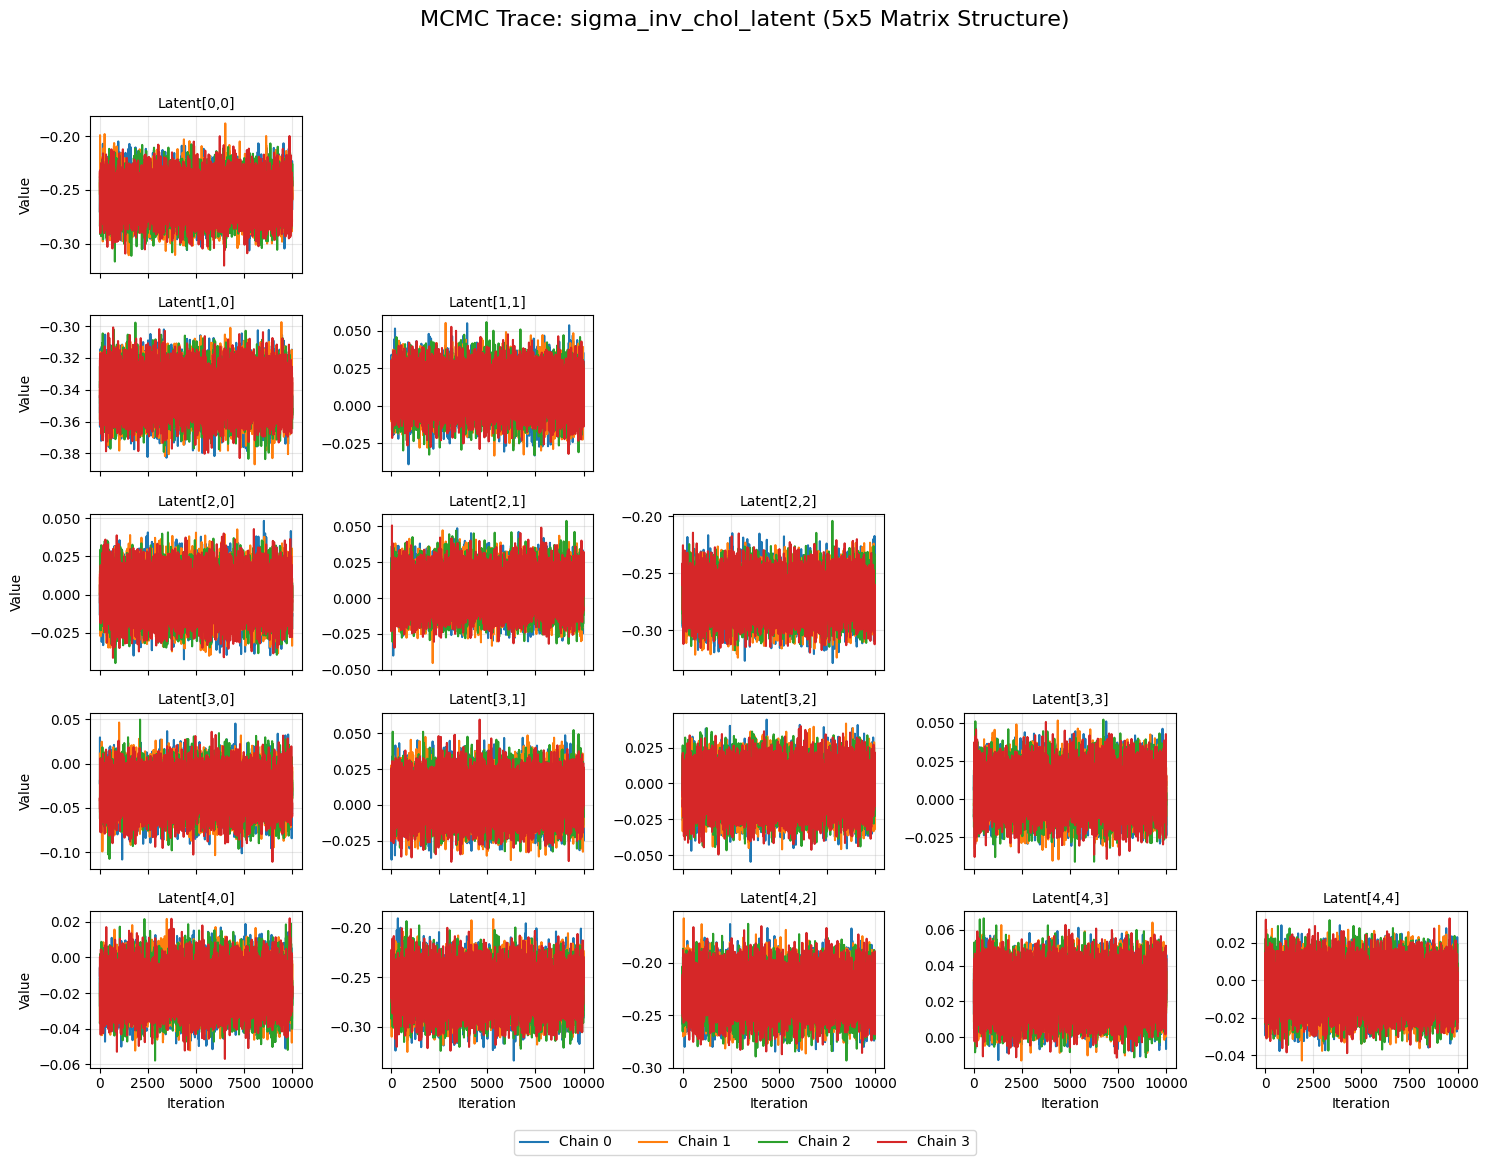

In [29]:
# Get the latent samples
# Shape: (chains, draws, 15)
latent_samples = results.get_posterior_samples()["sigma_inv_chol_latent"]
n_chains, n_draws, n_latent = latent_samples.shape

# Setup a 5x5 grid
fig, axes = plt.subplots(5, 5, figsize=(15, 12), sharex=True, sharey=False)

# Counter to keep track of which of the 15 parameters we are plotting
latent_idx = 0

for i in range(5):        # Rows
    for j in range(5):    # Columns
        ax = axes[i, j]
        
        # In a 5x5 lower triangular matrix, parameters exist only where i >= j
        if i >= j and latent_idx < n_latent:
            for chain in range(n_chains):
                ax.plot(latent_samples[chain, :, latent_idx], alpha=1, label=f"Chain {chain}")
            
            ax.set_title(f"Latent[{i},{j}]", fontsize=10)
            latent_idx += 1
        else:
            # Hide axes for the upper triangle where there is no data
            ax.axis('off')
        
        # Grid and formatting
        ax.grid(True, alpha=0.3)
        if i == 4:
            ax.set_xlabel("Iteration")
        if j == 0:
            ax.set_ylabel("Value")

# Add a single legend for the whole figure
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=n_chains, bbox_to_anchor=(0.5, 0.02))

plt.suptitle("MCMC Trace: sigma_inv_chol_latent (5x5 Matrix Structure)", fontsize=16)
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

In [30]:
# Setup the bijector (must match the one in the model)
bijector = tfb.FillScaleTriL()

# Function to turn 1D vector -> 5x5 Matrix -> Covariance Matrix
def latent_to_sigma(latent_vec):
    # Map 15-dim vector to 5x5 Lower Triangular Matrix (L)
    L = bijector.forward(latent_vec)

    # Compute Precision (Omega = L @ L.T)
    # Invert to get Covariance (Sigma = inv(Omega))
    # This is equivalent to inv(L.T) @ inv(L) which is more stable
    precision_mat = L @ L.T
    return jnp.linalg.inv(precision_mat)

# Vectorize across chains and draws
v_latent_to_sigma = jax.vmap(jax.vmap(latent_to_sigma))
sigma_samples = v_latent_to_sigma(latent_samples)

# Quick comparison of true values and posterior mean
sigma_posterior_mean = jnp.mean(sigma_samples, axis=(0, 1))

print("--- Comparison of Covariance Matrices ---")
print("\nTrue Sigma (Simulation):")
print(np.round(data["true_Sigma"], 3))

print("\nEstimated Sigma (Posterior Mean):")
print(jnp.round(sigma_posterior_mean, 3))

--- Comparison of Covariance Matrices ---

True Sigma (Simulation):
[[3.0000002 0.        0.        0.        0.       ]
 [0.        3.0000002 0.        0.        0.       ]
 [0.        0.        3.0000002 0.        0.       ]
 [0.        0.        0.        3.0000002 1.5000001]
 [0.        0.        0.        1.5000001 3.0000002]]

Estimated Sigma (Posterior Mean):
[[ 3.1150002   0.09        0.017      -0.047      -0.047     ]
 [ 0.09        3.078      -0.12900001  0.016       0.007     ]
 [ 0.017      -0.12900001  2.9180002  -0.052      -0.066     ]
 [-0.047       0.016      -0.052       2.9490001   1.5320001 ]
 [-0.047       0.007      -0.066       1.5320001   3.045     ]]


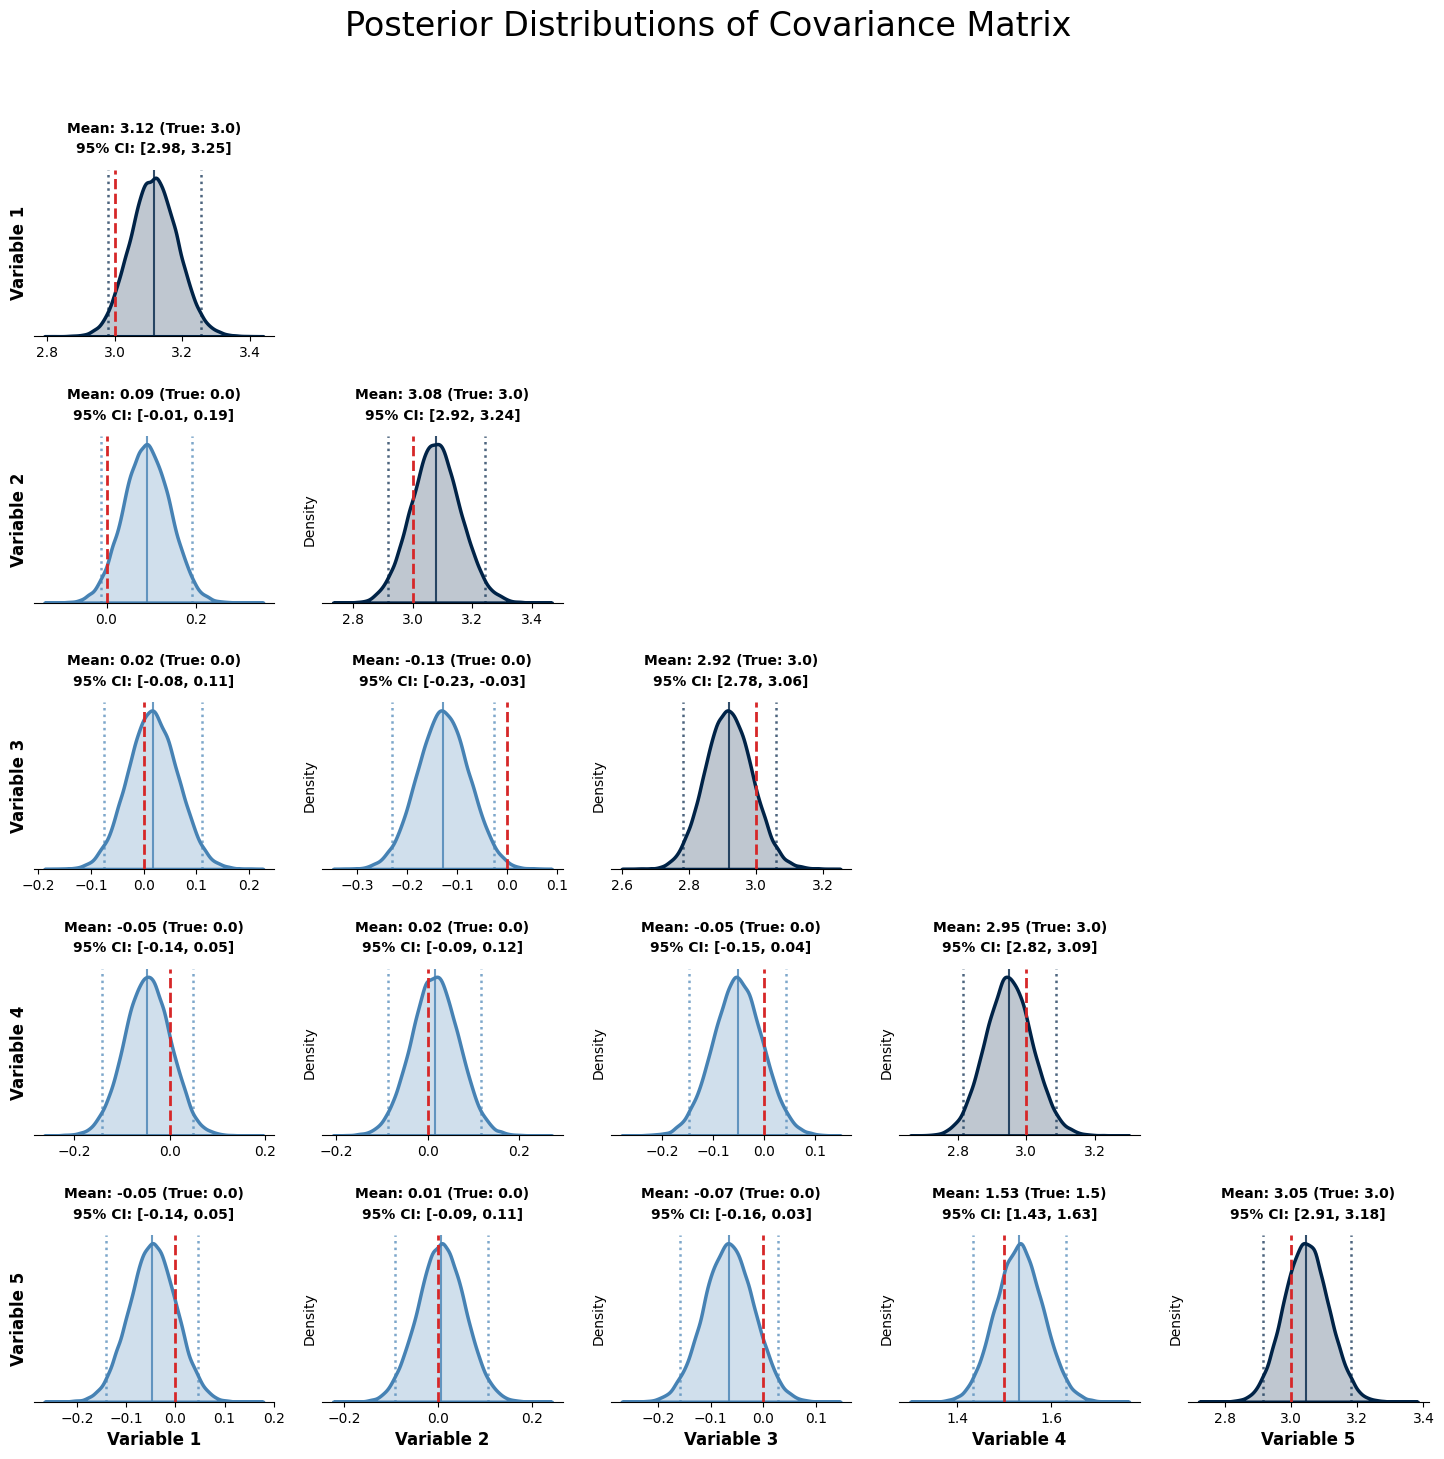

In [31]:
def plot_final_covariance_complete(samples, true_matrix=None):
    n_dim = samples.shape[-1]
    # Extra large figure for maximum readability
    _, axes = plt.subplots(n_dim, n_dim, figsize=(18, 16))
    
    flattened_samples = samples.reshape(-1, n_dim, n_dim)
    
    # Color Palette
    diag_color =     "#002347"
    off_diag_color = "#4682B4"
    true_val_color = "#D62728"

    for i in range(n_dim):
        for j in range(n_dim):
            ax = axes[i, j]
            
            # 1. Lower Triangular Logic
            if j > i:
                ax.axis('off')
                continue
            
            data = flattened_samples[:, i, j]
            is_diag = (i == j)
            current_color = diag_color if is_diag else off_diag_color
            
            # 2. Stats Calculation
            post_mean = np.mean(data)
            ci_low, ci_high = np.percentile(data, [2.5, 97.5])
            
            # 3. Plot KDE
            sns.kdeplot(data, ax=ax, fill=True, color=current_color, alpha=0.25, lw=2.5)
            
            # 4. Reference Lines
            # Mean line (Solid)
            ax.axvline(post_mean, color=current_color, linestyle="-", lw=1.5, alpha=0.8)
            
            # 95% CI Lines (Dotted)
            ax.axvline(ci_low, color=current_color, linestyle=":", lw=1.8, alpha=0.7)
            ax.axvline(ci_high, color=current_color, linestyle=":", lw=1.8, alpha=0.7)
            
            # True Value (Dashed Red)
            if true_matrix is not None:
                true_val = true_matrix[i, j]
                ax.axvline(true_val, color=true_val_color, linestyle="--", lw=2)
            
            # 5. Textual Labels (Title with CI stated)
            title_str = (
                f"Mean: {post_mean:.2f} "
                f"({'True: ' + str(round(true_val, 2)) if true_matrix is not None else ''})\n"
                f"95% CI: [{ci_low:.2f}, {ci_high:.2f}]"
            )
            ax.set_title(title_str, fontsize=10, pad=12, linespacing=1.6, fontweight='bold')

            # 6. Aesthetic Polish
            ax.set_yticks([])
            sns.despine(ax=ax, left=True)
            
            # Label only the edges to keep it clean
            if i == n_dim - 1:
                ax.set_xlabel(f"Variable {j+1}", fontsize=12, fontweight='bold')
            if j == 0:
                ax.set_ylabel(f"Variable {i+1}", fontsize=12, fontweight='bold')

    plt.suptitle("Posterior Distributions of Covariance Matrix", 
                 fontsize=24, y=0.98, fontweight='light')
    
    # Spacing to prevent cramping and accommodate multi-line titles
    plt.subplots_adjust(hspace=0.6, wspace=0.2)
    plt.show()

# Run the plot
plot_final_covariance_complete(sigma_samples, data["true_Sigma"])

In [1]:
def plot_detailed_param(results_dict, param_name, param_indices):
    """
    Plot detailed diagnostics for a parameter.
    param_indices can be a single int or list of ints.
    """
    if isinstance(param_indices, int):
        param_indices = [param_indices]
    for idx in param_indices:
        print(f"Detailed Diagnostics: {param_name}[{idx}]")
        gs.plot_param(results_dict, param_name, param_index=idx)
        plt.show()